 Customer Intelligence System using classification, ensemble & clustering.


Techniques Used:
- Exploratory Data Analysis (EDA)
- Principal Component Analysis (PCA)
- K-Means Clustering

Models Used:
- Random Forest
- XGBoost


## 1. Imports

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [92]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

## 2. Data Loading & Exploratory Analysis

In [93]:
df = pd.read_csv('Country-data.csv')
print(df.shape)
print(df.isnull().sum())
df.head(10)


(167, 10)
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


In [94]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


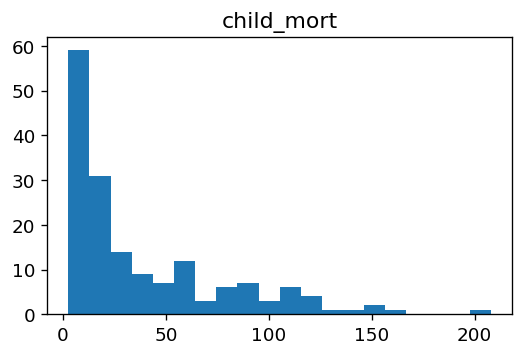

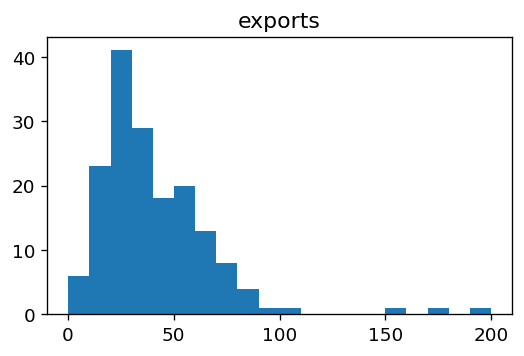

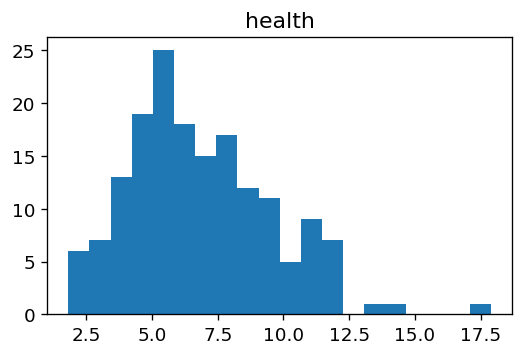

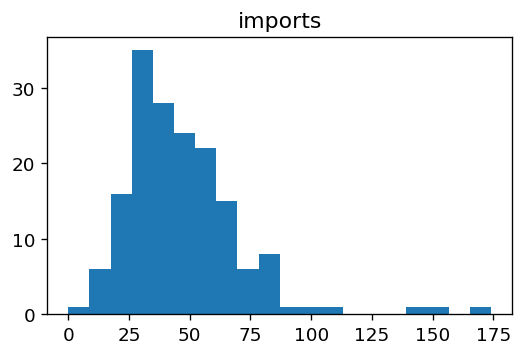

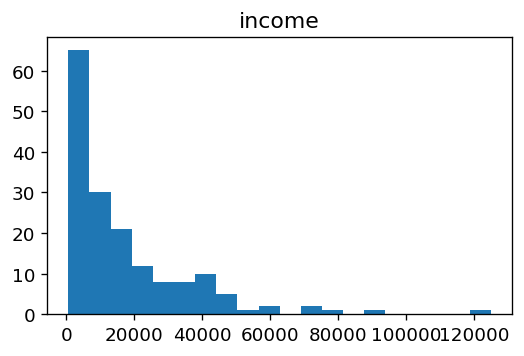

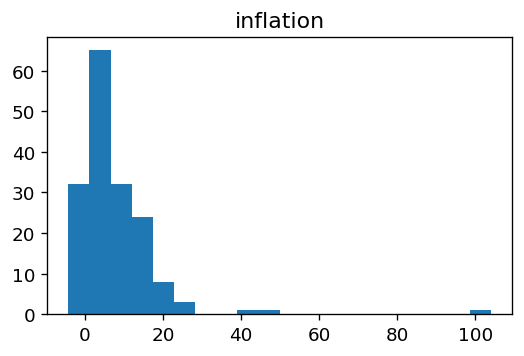

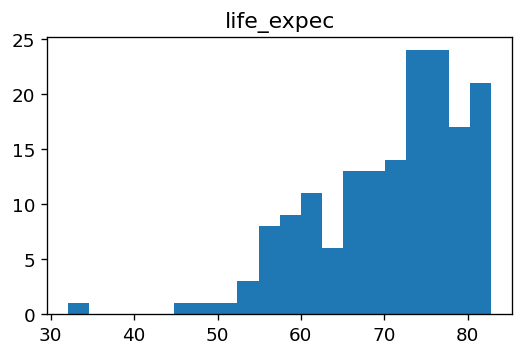

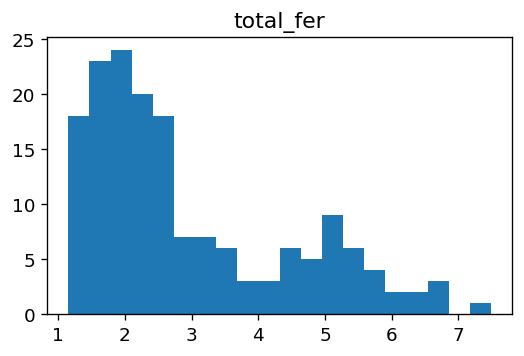

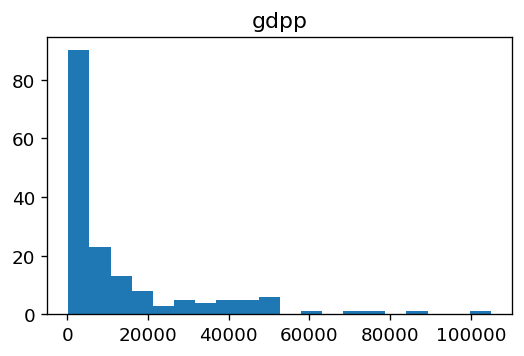

In [95]:
# # Distribution plots for all features
for col in features:
    plt.figure(figsize=(5,3))
    plt.hist(df[col], bins=20)
    plt.title(col)
    plt.show()


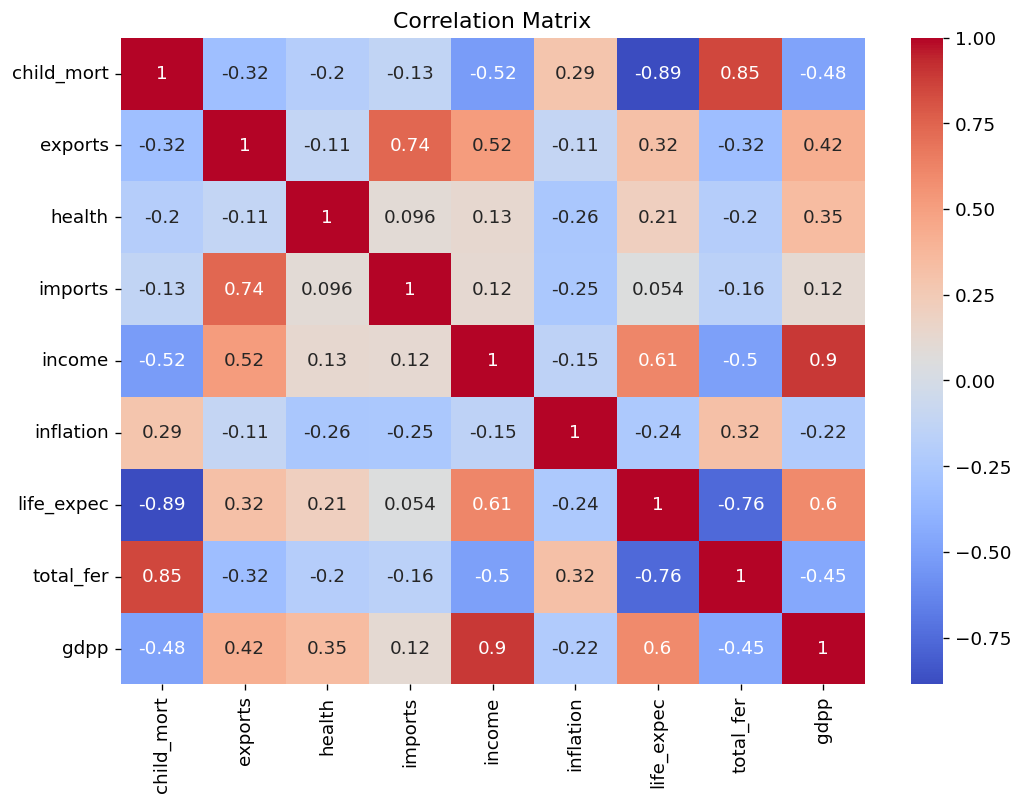

In [96]:
# Correlation heatmap
corr = df[features].corr()
plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## 3. Feature Engineering & Target Creation

In [97]:
df["development_score"] =(df["gdpp"] +df["life_expec"] -df["child_mort"])

Class Distribution
dev_class
0    55
1    57
2    55
Name: count, dtype: int64


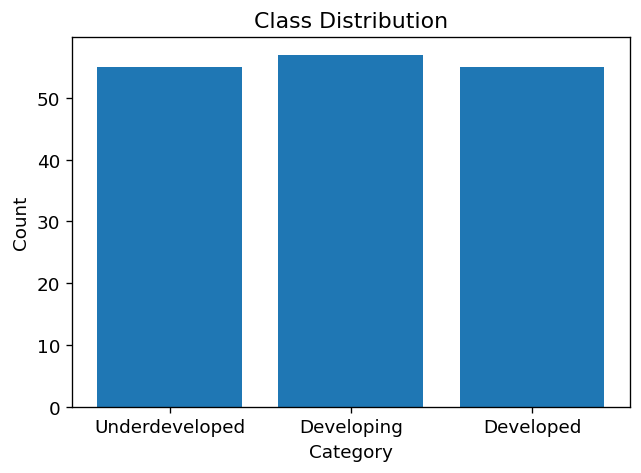

In [98]:
# Create development score

df["development_score"] = ((1 / (df["child_mort"] + 1)) +(df["life_expec"] / df["life_expec"].max())+(df["gdpp"] / df["gdpp"].max()) +(df["health"] / df["health"].max()))

bins = df["development_score"].quantile([0, 0.33, 0.67, 1]).values

df["dev_class"] = pd.cut(
    df["development_score"],
    bins=bins,
    labels=[0, 1, 2],
    include_lowest=True
)

df["dev_class"] = df["dev_class"].astype(int)

class_names = [
    "Underdeveloped",
    "Developing",
    "Developed"
]
print("Class Distribution")
print(df["dev_class"].value_counts().sort_index())
counts = df["dev_class"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(class_names, counts.values)

plt.title("Class Distribution")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

## 4. Preprocessing & Train-Test Split

In [99]:
X = df[features]
y = df["dev_class"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples :", len(X_train))
print("Testing samples  :", len(X_test))

Training samples : 133
Testing samples  : 34


## 5. Random Forest Classifier

In [100]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy :", acc)
print(classification_report(y_test, y_pred))

Accuracy : 0.9117647058823529
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.83      0.91      0.87        11
           2       1.00      0.92      0.96        13

    accuracy                           0.91        34
   macro avg       0.91      0.91      0.91        34
weighted avg       0.92      0.91      0.91        34



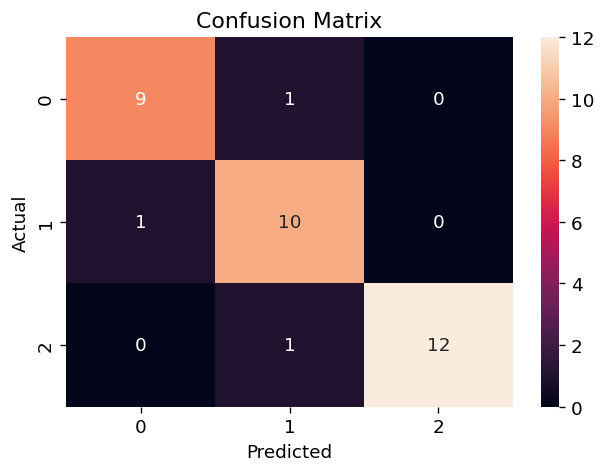

In [101]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

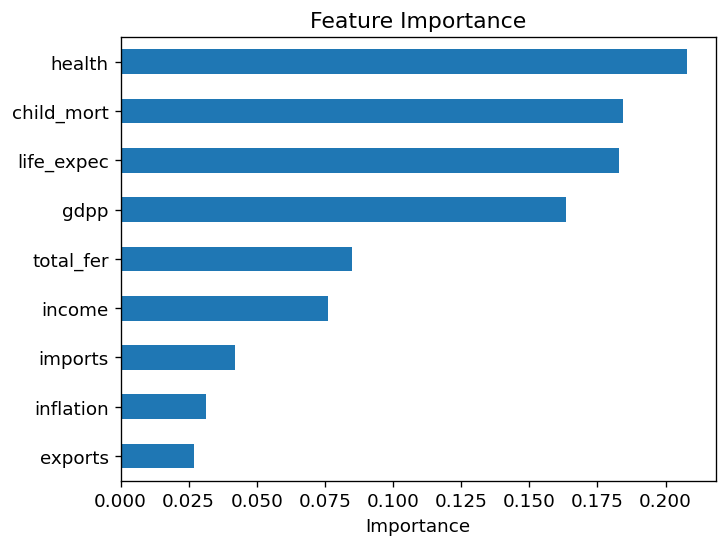

In [102]:


importance = pd.Series(
    rf.feature_importances_,
    index=features
)

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance")
plt.xlabel("Importance")

plt.show()

## 6. XGBoost Classifier

In [103]:
xgb = XGBClassifier(
    n_estimators=100,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)
print(classification_report(y_test, y_pred))

Accuracy : 0.8823529411764706
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.77      0.91      0.83        11
           2       1.00      0.85      0.92        13

    accuracy                           0.88        34
   macro avg       0.89      0.89      0.88        34
weighted avg       0.90      0.88      0.88        34



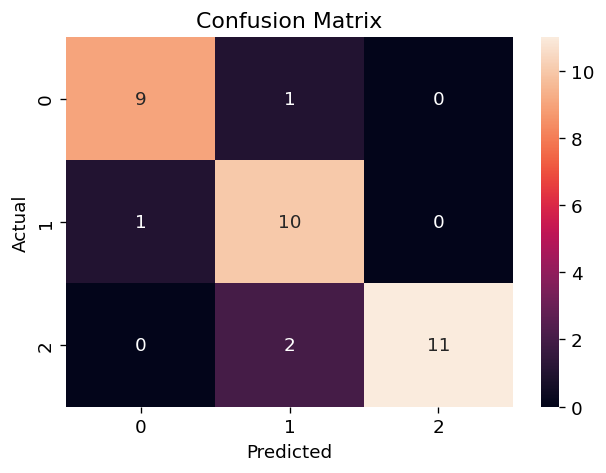

In [104]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

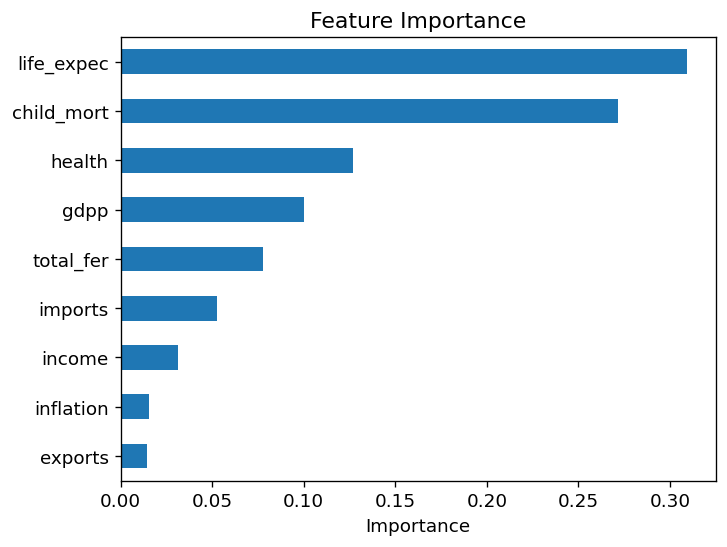

In [105]:
importance = pd.Series(
    xgb.feature_importances_,
    index=features
)

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance")
plt.xlabel("Importance")

plt.show()

## 7. Soft Voting Ensemble (RF + XGBoost)

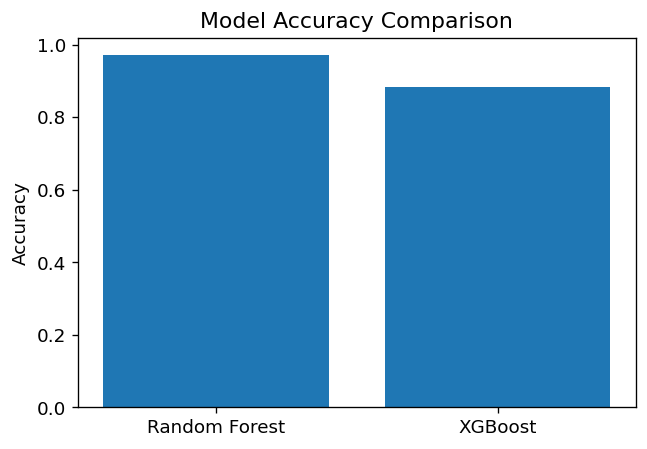

In [106]:
models = ["Random Forest", "XGBoost"]
scores = [rf_acc, accuracy]

plt.figure(figsize=(6,4))
plt.bar(models, scores)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

In [107]:
print("Project Completed")

print("Random Forest Accuracy :", rf_acc)
print("XGBoost Accuracy :", accuracy)

if accuracy > rf_acc:
    print("XGBoost performed better.")
else:
    print("Random Forest performed better.")

Project Completed
Random Forest Accuracy : 0.9705882352941176
XGBoost Accuracy : 0.8823529411764706
Random Forest performed better.


## 8. K-Means Clustering

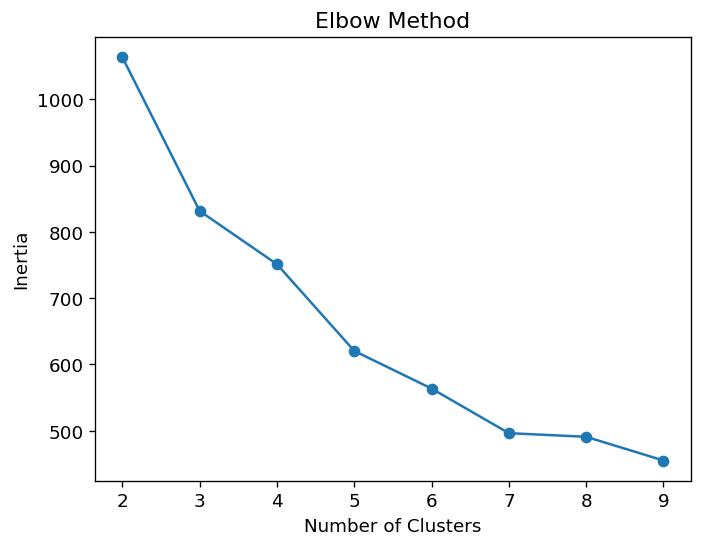

In [108]:
inertias = []

for k in range(2, 10):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_scaled)

    inertias.append(kmeans.inertia_)

plt.plot(range(2, 10), inertias, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [109]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

print("Cluster Summary")
print(df.groupby("kmeans_cluster")[features].mean())

Cluster Summary
                child_mort    exports    health    imports        income  \
kmeans_cluster                                                             
0                22.456977  40.273128  6.251047  47.362394  12321.744186   
1                 5.000000  58.738889  8.807778  51.491667  45672.222222   
2                95.106667  28.602444  6.301111  42.306667   3539.844444   

                inflation  life_expec  total_fer          gdpp  
kmeans_cluster                                                  
0                7.720884   72.566279   2.340349   6461.767442  
1                2.671250   80.127778   1.752778  42494.444444  
2               11.986778   59.055556   5.065333   1766.711111  


## 9. DBSCAN Clustering

In [110]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

print("Cluster Summary")
print(df.groupby("kmeans_cluster")[features].mean())

Cluster Summary
                child_mort    exports    health    imports        income  \
kmeans_cluster                                                             
0                22.456977  40.273128  6.251047  47.362394  12321.744186   
1                 5.000000  58.738889  8.807778  51.491667  45672.222222   
2                95.106667  28.602444  6.301111  42.306667   3539.844444   

                inflation  life_expec  total_fer          gdpp  
kmeans_cluster                                                  
0                7.720884   72.566279   2.340349   6461.767442  
1                2.671250   80.127778   1.752778  42494.444444  
2               11.986778   59.055556   5.065333   1766.711111  


In [111]:
db = DBSCAN(eps=eps_val, min_samples=4)
db_labels = db.fit_predict(X_scaled)
df['dbscan_cluster'] = db_labels

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
noise_pct     = (db_labels == -1).sum() / len(db_labels) * 100

print(f"DBSCAN Clusters Found : {n_clusters_db}")
print(f"Noise Points          : {(db_labels==-1).sum()} ({noise_pct:.1f}%)")
print(f"Core Points           : {(db_labels!=-1).sum()}")


DBSCAN Clusters Found : 1
Noise Points          : 9 (5.4%)
Core Points           : 158


## 10. PCA Dimensionality Reduction & Cluster Visualisation

Variance Explained : 0.6313336543771411


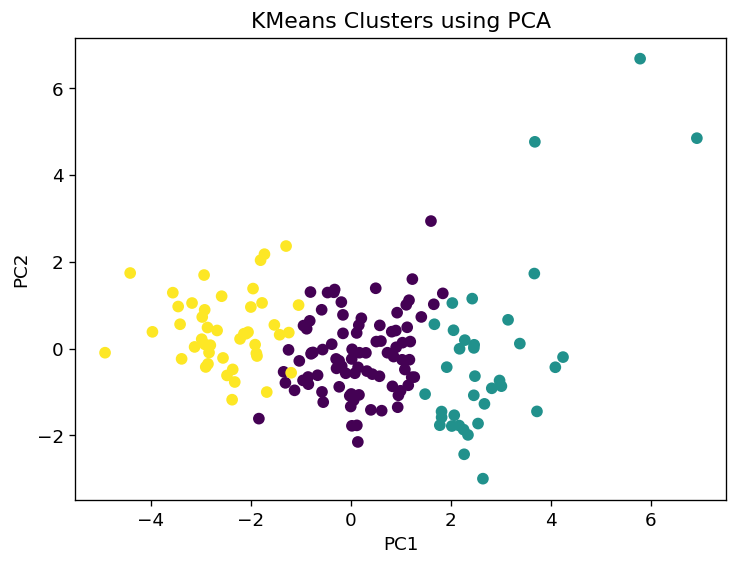

In [112]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Variance Explained :", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(7,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["kmeans_cluster"]
)

plt.title("KMeans Clusters using PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

## 11. Customer Segmentation 

In [113]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

In [114]:
# Number of countries in each cluster

print(df["kmeans_cluster"].value_counts())

# Average values of important features

cluster_summary = df.groupby("kmeans_cluster")[
    ["gdpp", "life_expec", "income", "child_mort"]
].mean()

print(cluster_summary)

kmeans_cluster
0    86
2    45
1    36
Name: count, dtype: int64
                        gdpp  life_expec        income  child_mort
kmeans_cluster                                                    
0                6461.767442   72.566279  12321.744186   22.456977
1               42494.444444   80.127778  45672.222222    5.000000
2                1766.711111   59.055556   3539.844444   95.106667


In [ ]:

print("Cluster Summary")
cluster_summary = df.groupby("kmeans_cluster")[features].mean()
print(cluster_summary)

Cluster Summary
                child_mort    exports    health    imports        income  \
kmeans_cluster                                                             
0                22.456977  40.273128  6.251047  47.362394  12321.744186   
1                 5.000000  58.738889  8.807778  51.491667  45672.222222   
2                95.106667  28.602444  6.301111  42.306667   3539.844444   

                inflation  life_expec  total_fer          gdpp  
kmeans_cluster                                                  
0                7.720884   72.566279   2.340349   6461.767442  
1                2.671250   80.127778   1.752778  42494.444444  
2               11.986778   59.055556   5.065333   1766.711111  


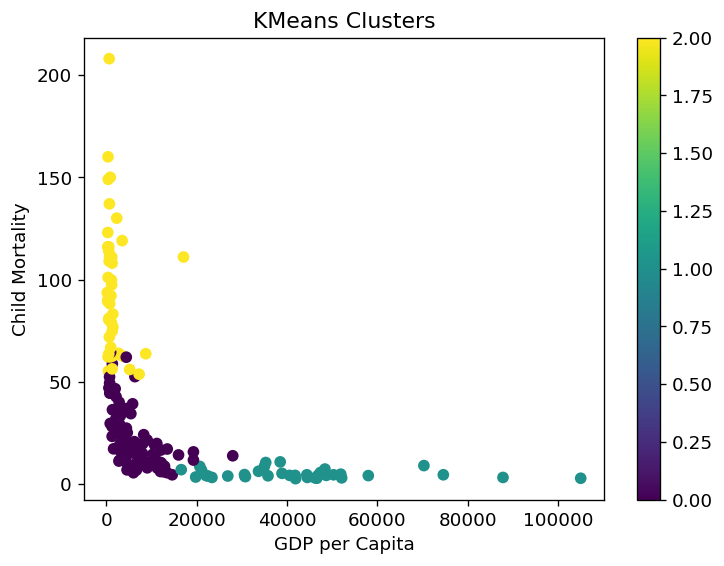

In [116]:
plt.figure(figsize=(7,5))

scatter = plt.scatter(
    df["gdpp"],
    df["child_mort"],
    c=df["kmeans_cluster"]
)

plt.xlabel("GDP per Capita")
plt.ylabel("Child Mortality")
plt.title("KMeans Clusters")

plt.colorbar(scatter)

plt.show()

## 12. Results Summary & Insights

In [117]:
print("Project Summary")
print("Random Forest Accuracy :", rf_acc)
print("XGBoost Accuracy :", accuracy)
print("\nCluster Summary")
print(df.groupby("kmeans_cluster")[features].mean())

Project Summary
Random Forest Accuracy : 0.9705882352941176
XGBoost Accuracy : 0.8823529411764706

Cluster Summary
                child_mort    exports    health    imports        income  \
kmeans_cluster                                                             
0                22.456977  40.273128  6.251047  47.362394  12321.744186   
1                 5.000000  58.738889  8.807778  51.491667  45672.222222   
2                95.106667  28.602444  6.301111  42.306667   3539.844444   

                inflation  life_expec  total_fer          gdpp  
kmeans_cluster                                                  
0                7.720884   72.566279   2.340349   6461.767442  
1                2.671250   80.127778   1.752778  42494.444444  
2               11.986778   59.055556   5.065333   1766.711111  


## Conclusion

In this project, I analyzed country-level data using machine learning techniques.

I first performed exploratory data analysis and feature analysis. After preprocessing and scaling the data, I trained Random Forest and XGBoost models for classification.

Both models achieved good accuracy on the dataset.

I also applied K-Means clustering to group countries with similar characteristics and used PCA to visualize the clusters in two dimensions.

The results show that economic and health-related indicators such as GDP per capita, life expectancy, income, and child mortality play an important role in distinguishing different development levels.